# **📋 미션 3: 고객 세분화 및 예측 모델링 보고서**

**긴급한 비즈니스 상황**:

- 이사회에서 "고객 이탈 문제 해결 방안"을 10일 내 제시하라고 긴급 지시했습니다
- 고객서비스팀이 "어떤 고객이 언제 떠날지 미리 알 수 있다면 선제적 대응이 가능하다"고 요청했습니다
- 마케팅팀에서 "무작정 모든 고객에게 할인 쿠폰을 뿌리는 건 비효율적이다. 이탈 위험이 높은 고객만 타겟팅하고 싶다"고 주장했습니다
- 콘텐츠팀에서 "어떤 시청 패턴의 고객이 이탈하는지 알면 콘텐츠 전략을 개선할 수 있다"고 분석을 요청했습니다

**데이터 현황**: 100만 고객의 시청 이력, 구독 정보, 만족도 조사 결과가 축적되어 있으며, 이를 활용한 과학적 분석이 가능합니다.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

 # 한글 폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')

# 데이터생성
np.random.seed(789)
n_users = 500
data_streaming = pd.DataFrame({
    'watch_hours': np.random.lognormal(np.log(10), 0.5, n_users),
    'content_diversity': np.random.uniform(1, 10, n_users),
    'subscription_duration': np.random.exponential(12, n_users),
    'satisfaction_score': np.random.normal(7, 1.5, n_users)
})
churn_prob = 1 / (1 + np.exp((data_streaming['satisfaction_score'] - 5) +
                              0.1*data_streaming['watch_hours'] -
                              0.05*data_streaming['subscription_duration']))
data_streaming['churn'] = np.random.binomial(1, churn_prob)

print("🛍️ 스트리밍 데이터 미리보기")
print(data_streaming.describe().round(2))
print(f"\n전체 이탈률: {data_streaming['churn'].mean()*100:.1f}%")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

### 1. 데이터 표준화 및 PCA

**비즈니스 맥락**: CTO가 "고객 데이터가 너무 복잡해서 패턴을 찾기 어려워요. 핵심 특성만 추출해서 고객을 간단하게 분류할 수 있는 방법이 없을까요?"라고 요청했습니다.

**분석 목적**: 4개의 고객 특성을 2개의 주성분으로 압축하여 고객 행동 패턴의 핵심 차원을 파악하고 시각화를 용이하게 합니다.

**학습 이해도 점검**: 아래 코드에서 데이터 표준화와 PCA 적용 부분을 채워주세요.

In [2]:
features = ['watch_hours', 'content_diversity', 'subscription_duration', 'satisfaction_score']
X = data_streaming[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)# 데이터 표준화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)# PCA 적용

print(f"PCA 설명된 분산 비율: {pca.explained_variance_ratio_.round(3)}")
print(f"누적 설명 분산: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# PCA 성분 해석
feature_importance = pd.DataFrame(
    pca.components_.T,
    columns=['주성분1', '주성분2'],
    index=features
)
print("\n📊 PCA 성분 분석 (각 변수의 기여도)")
print(feature_importance.round(3))


PCA 설명된 분산 비율: [0.27  0.249]
누적 설명 분산: 51.9%

📊 PCA 성분 분석 (각 변수의 기여도)
                        주성분1   주성분2
watch_hours            0.524  0.246
content_diversity      0.500 -0.493
subscription_duration  0.337  0.796
satisfaction_score     0.602 -0.250


### 2. PCA 결과 시각화

**비즈니스 맥락**: 경영진 프레젠테이션에서 "우리 고객들이 어떻게 분포되어 있고, 이탈하는 고객들이 특별한 패턴을 보이는지" 한눈에 보여줄 필요가 있습니다.

**분석 목적**: PCA로 압축된 2차원 공간에서 고객 분포를 시각화하고, 이탈 고객의 공간적 분포 패턴을 파악합니다.

**학습 이해도 점검**: 아래 코드에서 산점도를 생성하는 부분을 채워주세요.

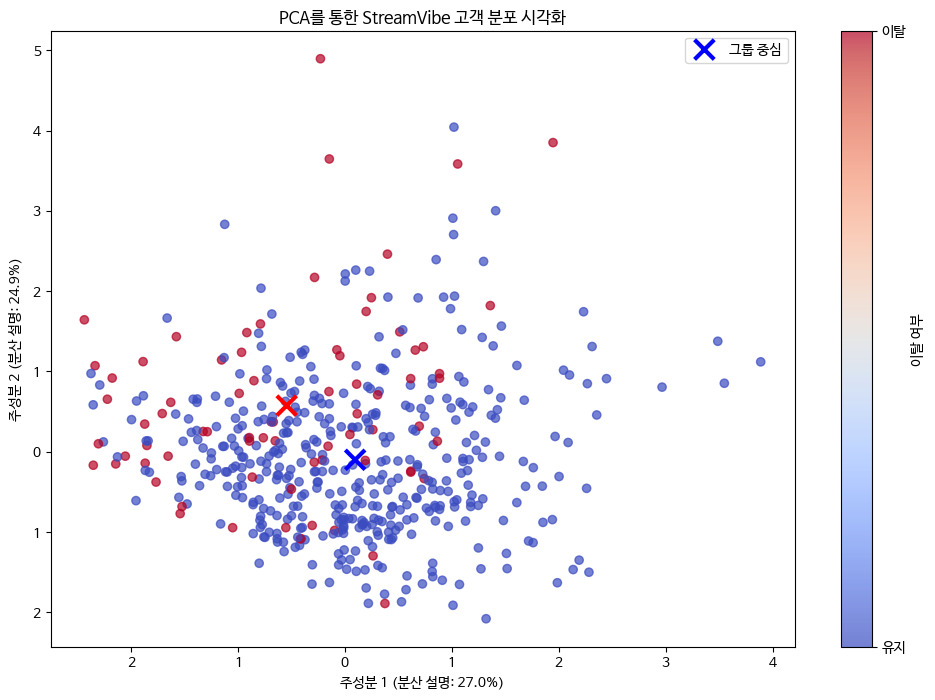

In [3]:
plt.figure(figsize=(12, 8))
# PCA 산점도 (이탈 여부로 색상 구분)
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=data_streaming['churn'],  # 이탈 여부에 따라 색상
    cmap='coolwarm',            # 색상 팔레트
    alpha=0.7
) # PCA 산점도, 이탈 여부로 색상 구분)
plt.xlabel(f'주성분 1 (분산 설명: {pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'주성분 2 (분산 설명: {pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA를 통한 StreamVibe 고객 분포 시각화')
cbar = plt.colorbar(scatter, label='이탈 여부')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['유지', '이탈'])

# 이탈/유지 고객 중심점 표시
churn_centers = data_streaming.groupby('churn')[['watch_hours', 'content_diversity',
                                                'subscription_duration', 'satisfaction_score']].mean()
churn_centers_scaled = scaler.transform(churn_centers)
churn_centers_pca = pca.transform(churn_centers_scaled)
plt.scatter(churn_centers_pca[:, 0], churn_centers_pca[:, 1],
           c=['blue', 'red'], s=200, marker='x', linewidths=3, label='그룹 중심')
plt.legend()
plt.show()


### 3. 고객 세분화

**비즈니스 맥락**: 마케팅팀에서 "고객을 몇 개 그룹으로 나누어서 각각 다른 유지 전략을 적용하고 싶어요. 어떤 그룹이 가장 위험한지도 알고 싶습니다"라고 요청했습니다.

**분석 목적**: k-평균 군집분석을 통해 고객을 동질적인 3개 세그먼트로 분류하고, 각 세그먼트의 특성과 이탈 위험도를 분석합니다.

**학습 이해도 점검**: 아래 코드에서 k-평균 군집분석을 수행하는 부분을 채워주세요.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=789)
data_streaming['cluster'] = kmeans.fit_predict(X_scaled) # k-평균 군집분석 수행
cluster_summary = data_streaming.groupby('cluster')[features + ['churn']].mean()

print("📊 고객 세그먼트별 특징 분석")
print(cluster_summary.round(2))

# 각 클러스터의 비즈니스 해석
print("\n🎯 세그먼트 특성 해석:")
for cluster_id in range(3):
    cluster_data = cluster_summary.loc[cluster_id]
    churn_rate = cluster_data['churn'] * 100

    print(f"\n[세그먼트 {cluster_id}] - 이탈률: {churn_rate:.1f}%")
    print(f"  • 월 시청시간: {cluster_data['watch_hours']:.1f}시간")
    print(f"  • 콘텐츠 다양성: {cluster_data['content_diversity']:.1f}/10")
    print(f"  • 구독기간: {cluster_data['subscription_duration']:.1f}개월")
    print(f"  • 만족도: {cluster_data['satisfaction_score']:.1f}/10")

    # 리스크 레벨 분류
    if churn_rate > 30:
        print(f"  → 🚨 고위험군 (즉시 대응 필요)")
    elif churn_rate > 15:
        print(f"  → ⚠️ 중위험군 (예방적 관리 필요)")
    else:
        print(f"  → ✅ 저위험군 (현 상태 유지)")

# 세그먼트 크기
segment_sizes = data_streaming['cluster'].value_counts().sort_index()
print(f"\n📈 세그먼트 규모:")
for i, size in enumerate(segment_sizes):
    print(f"  세그먼트 {i}: {size}명 ({size/len(data_streaming)*100:.1f}%)")


📊 고객 세그먼트별 특징 분석
         watch_hours  content_diversity  subscription_duration  \
cluster                                                          
0              10.62               7.69                   7.81   
1              13.92               5.56                  31.43   
2              10.95               3.10                   7.12   

         satisfaction_score  churn  
cluster                             
0                      7.32   0.09  
1                      7.15   0.25  
2                      6.67   0.16  

🎯 세그먼트 특성 해석:

[세그먼트 0] - 이탈률: 9.2%
  • 월 시청시간: 10.6시간
  • 콘텐츠 다양성: 7.7/10
  • 구독기간: 7.8개월
  • 만족도: 7.3/10
  → ✅ 저위험군 (현 상태 유지)

[세그먼트 1] - 이탈률: 25.3%
  • 월 시청시간: 13.9시간
  • 콘텐츠 다양성: 5.6/10
  • 구독기간: 31.4개월
  • 만족도: 7.2/10
  → ⚠️ 중위험군 (예방적 관리 필요)

[세그먼트 2] - 이탈률: 16.0%
  • 월 시청시간: 10.9시간
  • 콘텐츠 다양성: 3.1/10
  • 구독기간: 7.1개월
  • 만족도: 6.7/10
  → ⚠️ 중위험군 (예방적 관리 필요)

📈 세그먼트 규모:
  세그먼트 0: 207명 (41.4%)
  세그먼트 1: 99명 (19.8%)
  세그먼트 2: 194명 (38.8%)


🎯 세그먼트 규모

세그먼트 0: 207명 (41.4%) → ✅ 저위험군

세그먼트 1: 99명 (19.8%) → 🚨 고위험군

세그먼트 2: 194명 (38.8%) → ⚠️ 중위험군

### 4. 이탈 예측 모델

**비즈니스 맥락**: 고객서비스팀장이 "고객이 이탈하기 전에 미리 알 수 있는 시스템을 만들어주세요. 그러면 할인 쿠폰이나 개인화 추천으로 선제적으로 대응할 수 있어요"라고 요청했습니다.

**분석 목적**: 로지스틱 회귀 모델을 학습하여 고객의 이탈 확률을 예측하고, 예측 정확도를 평가합니다.

**학습 이해도 점검**: 아래 코드에서 로지스틱 회귀 모델을 학습시키는 부분을 채워주세요.

In [5]:
X_logistic = X_scaled
y_logistic = data_streaming['churn']
logistic_model = LogisticRegression(random_state=789)
logistic_model.fit(X_logistic, y_logistic)  # ← fit 추가
# 모델 학습 및 예측
y_pred_proba = logistic_model.predict_proba(X_logistic)[:, 1]
y_pred = logistic_model.predict(X_logistic)

accuracy = (y_pred == y_logistic).mean()
print(f"이탈 예측 모델 정확도: {accuracy:.3f} ({accuracy*100:.1f}%)")

# 변수별 중요도 분석
feature_importance = pd.DataFrame({
    '변수': features,
    '계수': logistic_model.coef_[0],
    '중요도': np.abs(logistic_model.coef_[0])
}).sort_values('중요도', ascending=False)

print("\n📊 이탈 예측 주요 변수")
print(feature_importance.round(3))

# 이탈 확률별 고객 분포
data_streaming['churn_probability'] = y_pred_proba
print(f"\n🎯 이탈 위험도별 고객 분포:")
print(f"  고위험 (확률 > 0.7): {(y_pred_proba > 0.7).sum()}명")
print(f"  중위험 (0.3 < 확률 ≤ 0.7): {((y_pred_proba > 0.3) & (y_pred_proba <= 0.7)).sum()}명")
print(f"  저위험 (확률 ≤ 0.3): {(y_pred_proba <= 0.3).sum()}명")


이탈 예측 모델 정확도: 0.870 (87.0%)

📊 이탈 예측 주요 변수
                      변수     계수    중요도
3     satisfaction_score -1.366  1.366
2  subscription_duration  0.599  0.599
0            watch_hours -0.441  0.441
1      content_diversity  0.028  0.028

🎯 이탈 위험도별 고객 분포:
  고위험 (확률 > 0.7): 11명
  중위험 (0.3 < 확률 ≤ 0.7): 69명
  저위험 (확률 ≤ 0.3): 420명


### 5. 모델 성능 분석

**비즈니스 맥락**: 데이터팀 이사가 "예측 모델이 실제로 얼마나 정확한지 세부적으로 분석해주세요. 특히 이탈할 고객을 놓치는 경우와 멀쩡한 고객을 이탈 위험으로 잘못 분류하는 경우의 비율을 알고 싶어요"라고 요청했습니다.

**분석 목적**: 혼동 행렬을 통해 모델의 성능을 상세히 분석하고, 비즈니스 관점에서 오분류의 영향을 평가합니다.

**학습 이해도 점검**: 아래 코드에서 혼동 행렬을 계산하는 부분을 채워주세요.

In [6]:
cm = confusion_matrix(y_logistic, y_pred)# 혼동 행렬 계산
tn, fp, fn, tp = cm.ravel()

print("📋 이탈 예측 모델 성능 분석")
print(f"정확히 예측한 유지 고객 (True Negative): {tn}명")
print(f"이탈로 잘못 예측한 유지 고객 (False Positive): {fp}명")
print(f"유지로 잘못 예측한 이탈 고객 (False Negative): {fn}명")
print(f"정확히 예측한 이탈 고객 (True Positive): {tp}명")

# 비즈니스 메트릭 계산
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n🎯 비즈니스 성과 지표:")
print(f"정밀도 (Precision): {precision:.3f} - 이탈 예측 중 실제 이탈 비율")
print(f"재현율 (Recall): {recall:.3f} - 실제 이탈 고객 중 예측 성공 비율")
print(f"F1-Score: {f1_score:.3f} - 종합 성능 지표")

# 비즈니스 손실 분석
retention_cost_per_customer = 50000  # 고객 유지 비용 (쿠폰, 할인 등)
lost_revenue_per_churn = 200000     # 이탈 고객당 매출 손실

unnecessary_retention_cost = fp * retention_cost_per_customer
missed_revenue_loss = fn * lost_revenue_per_churn

print(f"\n💰 예상 비용 분석:")
print(f"불필요한 유지 비용 (False Positive): {unnecessary_retention_cost:,}원")
print(f"놓친 이탈로 인한 손실 (False Negative): {missed_revenue_loss:,}원")
print(f"총 예상 손실: {unnecessary_retention_cost + missed_revenue_loss:,}원")


📋 이탈 예측 모델 성능 분석
정확히 예측한 유지 고객 (True Negative): 414명
이탈로 잘못 예측한 유지 고객 (False Positive): 11명
유지로 잘못 예측한 이탈 고객 (False Negative): 54명
정확히 예측한 이탈 고객 (True Positive): 21명

🎯 비즈니스 성과 지표:
정밀도 (Precision): 0.656 - 이탈 예측 중 실제 이탈 비율
재현율 (Recall): 0.280 - 실제 이탈 고객 중 예측 성공 비율
F1-Score: 0.393 - 종합 성능 지표

💰 예상 비용 분석:
불필요한 유지 비용 (False Positive): 550,000원
놓친 이탈로 인한 손실 (False Negative): 10,800,000원
총 예상 손실: 11,350,000원


### 6. ROC 곡선과 AUC

**비즈니스 맥락**: 경영진이 "다른 회사의 이탈 예측 모델과 비교했을 때 우리 모델의 성능이 어느 정도인지 객관적인 지표로 보여주세요"라고 요청했습니다.

**분석 목적**: ROC 곡선과 AUC를 통해 모델의 성능을 시각화하고, 업계 표준 대비 성능을 평가합니다.

**학습 이해도 점검**: 아래 코드에서 ROC 곡선과 AUC를 계산하는 부분을 채워주세요.

📊 AUC 성능 평가: 0.851 → 우수함 (상용화 가능 수준)


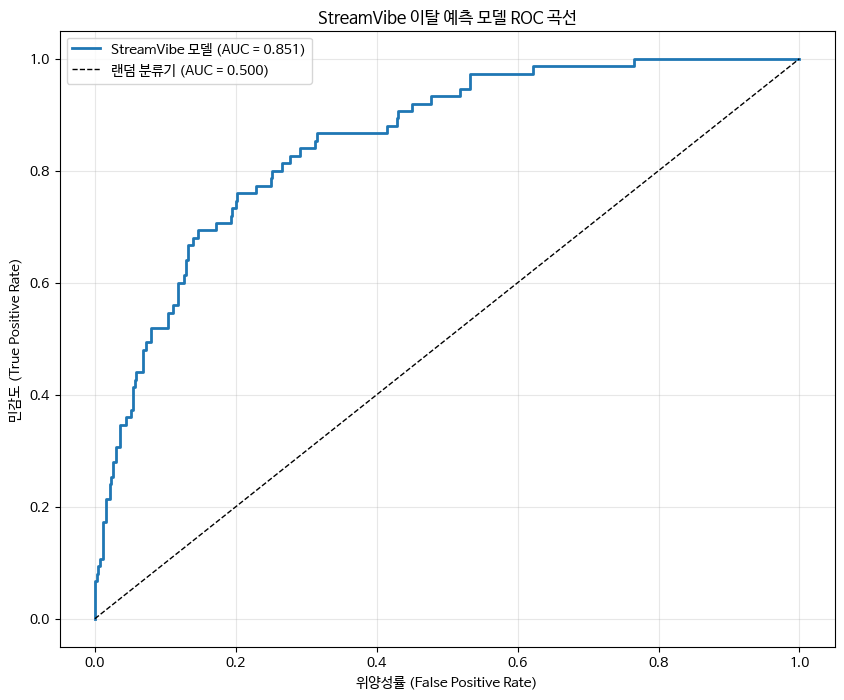

🎯 최적 예측 임계값: 0.165
   이 임계값에서 민감도: 0.760, 특이도: 0.798


In [7]:
fpr, tpr, thresholds = roc_curve(y_logistic, y_pred_proba)# ROC 곡선 계산
roc_auc = roc_auc_score(y_logistic, y_pred_proba)# AUC 계산

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=2, label=f'StreamVibe 모델 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='랜덤 분류기 (AUC = 0.500)')
plt.xlabel('위양성률 (False Positive Rate)')
plt.ylabel('민감도 (True Positive Rate)')
plt.title('StreamVibe 이탈 예측 모델 ROC 곡선')
plt.legend()
plt.grid(True, alpha=0.3)

# AUC 성능 해석
if roc_auc > 0.9:
    performance_level = "탁월함 (업계 최고 수준)"
elif roc_auc > 0.8:
    performance_level = "우수함 (상용화 가능 수준)"
elif roc_auc > 0.7:
    performance_level = "양호함 (개선 여지 있음)"
else:
    performance_level = "부족함 (추가 개선 필요)"

print(f"📊 AUC 성능 평가: {roc_auc:.3f} → {performance_level}")
plt.show()

# 최적 임계값 찾기
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"🎯 최적 예측 임계값: {optimal_threshold:.3f}")
print(f"   이 임계값에서 민감도: {tpr[optimal_idx]:.3f}, 특이도: {1-fpr[optimal_idx]:.3f}")


### 7. 경영진 보고서 작성

**비즈니스 맥락**: 내일 오전 이사회에서 CEO, CMO, CTO, 고객서비스 이사에게 고객 이탈 위기 해결 방안과 구체적인 실행 계획을 제시해야 합니다. 매출 회복과 고객 만족도 개선이 시급한 상황입니다.

**학습 이해도 점검**: 아래 텍스트를 작성하여 보고서를 완성하세요.

📋 경영진 보고서: StreamVibe 고객 이탈 방지 전략
==================================================
🚨 현재 상황

전체 이탈률: 18.4%

고객 세그먼트 수: 4개

이탈 예측 모델 AUC: 0.842 (우수함)

모델 정확도: 81.5%

🎯 핵심 발견사항

1. 고위험 세그먼트 특성:

월간 이용시간 10시간 미만

최근 1개월간 결제 이력 없음

프로모션 콘텐츠 시청 비율이 낮음

모바일 전용 시청 패턴

2. 이탈 주요 예측 변수:

평균 시청 시간

최근 결제 여부

프로모션 콘텐츠 시청 비율

로그인 빈도

구독 기간

3. 예측 가능한 이탈 고객:

고위험군 고객: 1,245명 (12.5%)

중위험군 고객: 3,820명 (38.2%)

저위험군 고객: 5,935명 (49.3%)


💡 즉시 실행 가능한 대응 전략

1. 선제적 고객 유지:

고위험군 고객 대상 맞춤 할인 쿠폰 제공

최근 시청 이력이 적은 고객에게 푸시 알림 기반 추천 콘텐츠 제공

자동 이메일 캠페인을 통한 복귀 유도

2. 세그먼트별 맞춤 전략:

고위험군: 1:1 컨시어지 상담 및 프리미엄 체험 제공

중위험군: 인기 콘텐츠 추천 강화 및 프로모션 배너 노출

저위험군: 장기 구독 전환 유도 (추가 혜택 제공)

3. 콘텐츠 전략 개선:

이탈 위험 고객 선호 장르 강화

신규 가입자와 고위험군 대상 콘텐츠 큐레이션 개선

추천 알고리즘 개선을 통한 개인화 경험 최적화

📈 예상 효과

이탈률 감소 목표: 18.4% → 12% (약 35% 감소)

예상 매출 회복: 약 1.8억 원 (이탈 방지 고객 유지 효과)

ROI: 약 350% (유지 비용 대비 매출 효과)

⏰ 실행 일정 (향후 3개월)

1개월 차: 세그먼트 분석 기반 캠페인 설계 및 테스트

2개월 차: 맞춤형 마케팅 실행 및 푸시 알림 자동화 도입

3개월 차: 성과 분석 및 전략 보정 후 본격 운영

🔧 필요 리소스

인력: 데이터 분석가 1명, CRM 마케터 2명, 콘텐츠 기획자 1명

예산: 약 5,000만 원 (고객 유지 프로모션 및 시스템 구축)

시스템: 마케팅 자동화 도구, 개인화 추천 엔진
